# Exercise: Creating Our Own Spectrogram

In this notebook we will learn how to create our own **spectrogram**.
A spectrogram is a visual representation of the prominent frequencies in audio samples *as they vary in time*.
That is, whereas plotting the the Fourier spectrum of a signal tells us what frequencies are prominent in the signal, a spectrogram will tell us what frequencies are prominent at any given time.
This is an extremely powerful tool for signal analysis.


In [23]:
# run this cell (maybe twice to get %matplotlib notebook to work)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
from microphone import record_audio
from typing import Tuple


## Accessing Time *and* Frequency: Building an Intuition for Spectrograms

Thus far we have seen two means for representing audio data visually. We have plotted:
1. Amplitude vs Time: Shows how the pressure from the sound wave varies over time.
2. Fourier Spectrum: Reveals the prominent frequencies that are present in the sound wave.

Let's revisit the clip of a trumpet playing a chord that we studied before.

In [24]:
import librosa

# `recorded_audio` is a numpy array of N audio samples
recorded_audio, sampling_rate = librosa.load("data/trumpet.wav", sr=44100, mono=True)

Let's play this audio clip to recall what is being played.

In [25]:
from IPython.display import Audio
Audio(recorded_audio, rate=sampling_rate)

### Revisiting the Fourier Spectrum

We'll plot both the temporal wave form/amplitude and its Fourier spectrum.
We will plot the Fourier coefficients, $|a_{k}|$, on a *log-scale*.
This is a natural scale to plot the Fourier spectrum on, as the human ear responds to loudness on a logarithmic scale (thus the common unit of "loudness", decibels [dB], used in audio science is a logarithmic scale).

[    0     1     2 ... 99997 99998 99999]


c:\Users\abhyu\dev\CogWorks\Week_1\week1\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\abhyu\dev\CogWorks\Week_1\week1\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


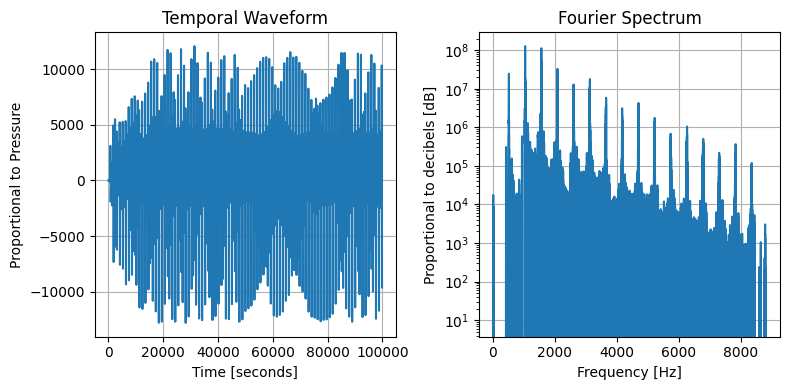

In [26]:
fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(8, 4))

# Compute the times at which each sample was recorded in seconds

# Define the following variable(s)
# `time`: array storing t_0, t_1, ..., t_{N-1} 
# STUDENT CODE HERE
time= np.arange(0, len(recorded_audio))  

print(time)

# Plotting the waveform (every 100th datapoint for sake of efficiency)
ax0.plot(time[::100], recorded_audio[::100])  
ax0.set_xlabel("Time [seconds]")
ax0.set_ylabel("Proportional to Pressure")
ax0.set_title("Temporal Waveform")
ax0.grid(True)


# Plotting the Fourier spectrum

# Compute the real-valued Fourier coefficents for this recording
# and the corresponding frequencies (in Hz)

# Define the following variable(s)
# `ak`: array storing the real-valued Fourier coeffs: a_0, a_1, ..., a_{N//2}
# `fk`: array storing the associated frequencies: 0/T, 1/T, ..., (N//2)/T
ak = np.fft.rfft(recorded_audio)
fk = np.fft.rfftfreq(len(recorded_audio), d=1/sampling_rate)
# STUDENT CODE HERE

ax1.plot(fk[:20000], ak[:20000])
ax1.set_title("Fourier Spectrum")
ax1.set_xlabel("Frequency [Hz]")
ax1.set_ylabel("Proportional to decibels [dB]")
ax1.grid(True)
ax1.set_yscale("log")
fig.tight_layout()

### Comparing a Fourier Spectrum to a Spectrogram

See that there is a trade-off between these two representations of the data.
That is, from the waveform we can see that the trumpet is playing a relatively sustained chord for about $2.5$ seconds, while we cannot glean from the wave form what notes are being played.
The Fourier spectrum reveals very clear information about the notes being played, but reveals nothing about the duration or ordering of the notes (are they being played in unison? in sequence? for how long? etc.).

We would like to know *what pure tone frequencies* are prominent in our signal and *when* they occur in our signal.
A **spectrogram** plots exactly this information. Without further ado, let's use matplotlib's built-in spectrogram function to understand what this visualization represents:

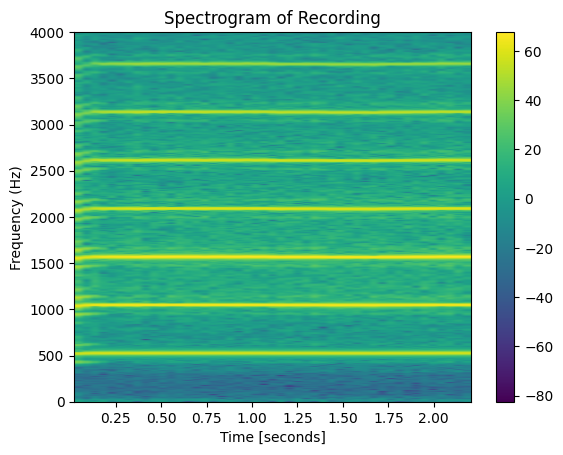

In [27]:
# using matplotlib's built-in spectrogram function
import matplotlib.mlab as mlab

fig, ax = plt.subplots()

S, freqs, times, im = ax.specgram(
    recorded_audio,
    NFFT=4096,
    Fs=sampling_rate,
    window=mlab.window_hanning,
    noverlap=4096 // 2,
    mode='magnitude',
    scale="dB"
)
fig.colorbar(im)

ax.set_xlabel("Time [seconds]")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Spectrogram of Recording")
ax.set_ylim(0, 4000);

The spectrogram displays a heat map which reflects the magnitude (i.e. absolute value) of the Fourier coefficients for a given time and frequency.
For example the yellow horizontal streak near $1000\;\mathrm{Hz}$ indicates that this frequency is prominent throughout the duration of the signal.
Note that this spectrogram function is automatically plotting these magnitudes on a log-scale, for the reasons discussed earlier.
This plot reveals that the prominent notes are being played in unison, and sustained for roughly $2.5$ seconds. We can also easily read off the frequencies of these notes and their [overtones](https://en.wikipedia.org/wiki/Overtone).

(1.7.1) Create the function, `plot_recording`, that:

- Accepts a time-length, in seconds 
- Uses `microphone.record_audio` to record audio for that duration of time. Recall that this returns "frames" of audio data and the microphone's sampling rate. (Refer to the `WorkingWithMic` notebook for reference)
- Converts the "frames" of audio data to a numpy array of 16-bit samples, using `np.hstack([np.frombuffer(i, np.int16) for i in frames])`
- Uses `mlab.specgram` to plot the spectrogram for that recording, given those 16-bit samples and the microphone's sampling rate
- Returns the matplotlib `Figure` and `Axes` object instances that were produced by the plot

Set the $y$-limit of the plot to have an upper bound of $10,000\;\mathrm{Hz}$.
Don't change any of the spectrogram settings other than the audio samples that you pass in and the sampling rate of the microphone.

In [28]:
def plot_recording(time: float) -> Tuple[plt.Figure, plt.Axes]:
    """ 
    Record audio and plot its spectrogram.
    
    Parameters
    ----------
    time : float
        The duration (seconds) to record audio for
    
    Returns
    -------
    fig, ax
        The plot objects for the spectrogram"""
    # STUDENT CODE HERE
    frames, sampling_rate = record_audio(time)
    audio_samples=np.hstack([np.frombuffer(i, np.int16) for i in frames])
    fig, ax = plt.subplots()
    ax.specgram(audio_samples, Fs=sampling_rate)
    Pxx, freqs, bins = mlab.specgram(audio_samples, Fs=sampling_rate)
    fig, ax = plt.subplots()
    cax = ax.imshow(10 * np.log10(Pxx), aspect='auto', origin='lower',
                   extent=[bins[0], bins[-1], freqs[0], freqs[-1]])
    fig.colorbar(cax, ax=ax)
    ax.set_ylim(0, 10000)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    return fig, ax


    


    

To continue building our intuition for the spectrogram, use `microphone.record_audio` to record a $5$ second clip of yourself whistling, clapping, etc.
Try varying the pitch, rhythm, etc. during the clip. Plot the clip as a spectrogram. 

Using input device 'Headset Microphone (Pixel USB-C earbuds)'
Recording ended


c:\Users\abhyu\dev\CogWorks\Week_1\week1\Lib\site-packages\matplotlib\axes\_axes.py:8280: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)
C:\Users\abhyu\AppData\Local\Temp\ipykernel_27100\955394904.py:21: RuntimeWarning: divide by zero encountered in log10
  cax = ax.imshow(10 * np.log10(Pxx), aspect='auto', origin='lower',


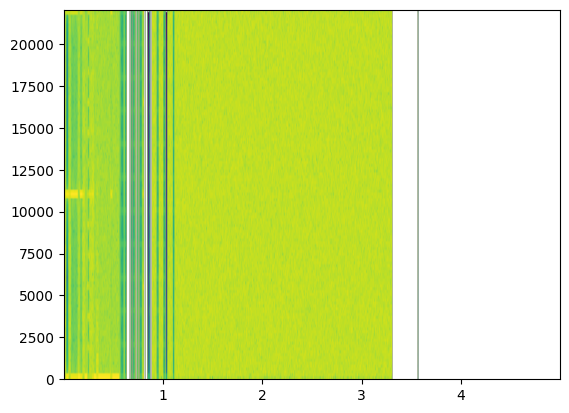

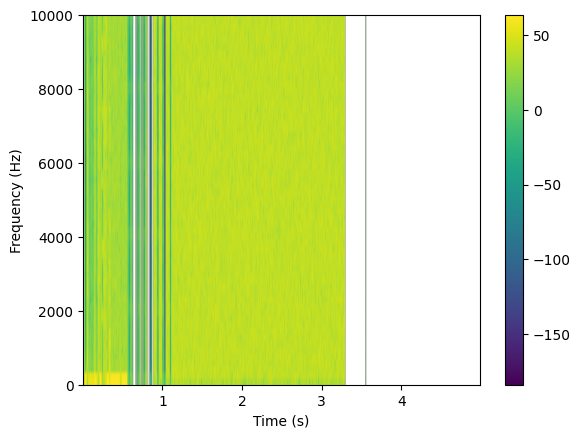

In [29]:
# STUDENT CODE HERE
fig, ax = plot_recording(5)
plt.show()

You should see that the spectrogram successfully captures both the prominent frequencies present in the signal and their dynamics in time. Try plotting several recordings where you whistle, clap, sing, etc. Can you see the correspondence between the sounds that you made and the patterns that manifest in the spectrogram?

Let's appreciate that we now have access to both frequency data and time data! This is extremely useful! Now how exactly is this working?

## Digging into Spectrograms

Our full recording consists of $N_\mathrm{total}$ audio samples $(y_{n})_{n=0}^{N_\mathrm{total}-1}$ recorded over a duration $T$ with some sampling rate $f_s$.

A spectrogram is constructed simply by dividing your samples into $M$ temporal windows, each of time-length $\Delta t$ and consisting of $N$ samples, where $N$ is determined by the duration $\Delta t$ and $f_s$: $N = \Delta t f_s$. 

\begin{equation}
\big\{(y_{n})_{n=0}^{N_\mathrm{total}-1}\big\}_{T} \Longrightarrow
\begin{bmatrix}
    \leftarrow   &  \big\{(y_{n})_{n=0}^{N-1}\big\}_{\Delta t_{0}} & \rightarrow  \\
    \leftarrow   &  \big\{(y_{n})_{n=0}^{N-1}\big\}_{\Delta t_{1}}  & \rightarrow \\
    & \vdots  &\\
    \leftarrow   &  \big\{(y_{n})_{n=0}^{N-1}\big\}_{\Delta t_{M-1}} & \rightarrow  \\
\end{bmatrix}
\end{equation}

We perform a discrete Fourier transform on the collection of samples for each given window.
This produces $M$ Fourier spectra – one for each temporal window's audio samples; this makes up each column of numbers in the spectrogram:

\begin{equation}
\begin{bmatrix}
    \leftarrow   &  \big\{(y_{n})_{n=0}^{N-1}\big\}_{\Delta t_{0}} & \rightarrow  \\
    \leftarrow   &  \big\{(y_{n})_{n=0}^{N-1}\big\}_{\Delta t_{1}} & \rightarrow \\
    & \vdots  &\\
    \leftarrow   &  \big\{(y_{n})_{n=0}^{N-1}\big\}_{\Delta t_{M-1}} & \rightarrow  \\
\end{bmatrix} 
\Longrightarrow 
\begin{bmatrix}
    \leftarrow   &  \big\{(c_{k})_{k=0}^{\lfloor N/2 \rfloor}\big\}_{\Delta t_{0}} & \rightarrow  \\
    \leftarrow   &  \big\{c_{k})_{k=0}^{\lfloor N/2 \rfloor}\big\}_{\Delta t_{1}}  & \rightarrow \\
    & \vdots  &\\
    \leftarrow   &  \big\{c_{k})_{k=0}^{\lfloor N/2 \rfloor}\big\}_{\Delta t_{M-1}} & \rightarrow  \\
\end{bmatrix} \Longrightarrow 
\begin{bmatrix}
    \leftarrow   &  \big\{(|a_{k}|)_{k=0}^{\lfloor N/2 \rfloor}\big\}_{\Delta t_{0}} & \rightarrow  \\
    \leftarrow   &  \big\{|a_{k}|)_{k=0}^{\lfloor N/2 \rfloor}\big\}_{\Delta t_{1}}  & \rightarrow \\
    & \vdots  &\\
    \leftarrow   &  \big\{|a_{k}|)_{k=0}^{\lfloor N/2 \rfloor}\big\}_{\Delta t_{M-1}} & \rightarrow  \\
\end{bmatrix} 
\end{equation}



If each temporal-window of our digital audio signal contains $N$ samples, then the Fourier transform on each window will produce $\left\lfloor\frac{N}{2}\right\rfloor + 1$ Fourier coefficients $(|a_{k}|)_{k=0}^{\lfloor N/2\rfloor}$.
Remember that we are interested in the *amplitude* of each Fourier coefficient, not its complex value, for the spectrogram.
This allows us to know what the frequency distribution is in our signal during each time-interval (a.k.a temporal window). 
The time window starts at $m\Delta t$ and ends at $(m+1)\Delta t$, for $m \in [0, 1, \dots, M-1]$.

**The *transpose* of the depicted array is what we plot in the spectrogram**: each column corresponds to one of $M$ temporal windows, and stores the Fourier spectrum of the audio recording during that time-interval.


The following function produces the same spectrogram as was plotted above, but without producing the associated plot;
let's get the spectrogram for the audio recording:

In [30]:
# obtaining the spectrogram for the trumpet wave form (again)

sampling_rate = 44100  # sampling rate in Hz

S, freqs, times = mlab.specgram(
    recorded_audio,
    NFFT=4096,
    Fs=sampling_rate,
    window=mlab.window_hanning,
    noverlap=int(4096 / 2),
    mode='magnitude'
)

`S` is the spectrogram, the 2-D array whose rows corresponds to frequencies and whose columns correspond to time.
`freqs` is an array of the frequency values corresponding to the rows, and `times` is an array of time values corresponding to the columns. Their units are Hz and seconds, respectively.

(1.7.2) Inspect the shapes of these arrays.
How many time bins, $M$, were used in the spectrogram?
How many frequency values are present in each time-bin?
Verify that the shape of `S` corresponds with the lengths of `freqs` and `times`.

In [31]:
# STUDENT CODE HERE
print("Spectrogram shape:", S.shape)
print("Spectrogram frequencies:", freqs)
print("Spectrogram times:", times)

Spectrogram shape: (2049, 47)
Spectrogram frequencies: [0.00000000e+00 1.07666016e+01 2.15332031e+01 ... 2.20284668e+04
 2.20392334e+04 2.20500000e+04]
Spectrogram times: [0.04643991 0.09287982 0.13931973 0.18575964 0.23219955 0.27863946
 0.32507937 0.37151927 0.41795918 0.46439909 0.510839   0.55727891
 0.60371882 0.65015873 0.69659864 0.74303855 0.78947846 0.83591837
 0.88235828 0.92879819 0.9752381  1.021678   1.06811791 1.11455782
 1.16099773 1.20743764 1.25387755 1.30031746 1.34675737 1.39319728
 1.43963719 1.4860771  1.53251701 1.57895692 1.62539683 1.67183673
 1.71827664 1.76471655 1.81115646 1.85759637 1.90403628 1.95047619
 1.9969161  2.04335601 2.08979592 2.13623583 2.18267574]


What are the sizes of the frequency bins (in Hz)?
Of the time bins (in seconds)?
Are the bins (nearly) uniform in size?

In [32]:
# STUDENT CODE HERE
# Compute frequency and time bin sizes
freq_bin_sizes = np.diff(freqs)
time_bin_sizes = np.diff(times)

print("Frequency bin sizes (Hz):", freq_bin_sizes)
print("Are frequency bins uniform?", np.allclose(freq_bin_sizes, freq_bin_sizes[0]))

print("Time bin sizes (s):", time_bin_sizes)
print("Are time bins uniform?", np.allclose(time_bin_sizes, time_bin_sizes[0]))


Frequency bin sizes (Hz): [10.76660156 10.76660156 10.76660156 ... 10.76660156 10.76660156
 10.76660156]
Are frequency bins uniform? True
Time bin sizes (s): [0.04643991 0.04643991 0.04643991 0.04643991 0.04643991 0.04643991
 0.04643991 0.04643991 0.04643991 0.04643991 0.04643991 0.04643991
 0.04643991 0.04643991 0.04643991 0.04643991 0.04643991 0.04643991
 0.04643991 0.04643991 0.04643991 0.04643991 0.04643991 0.04643991
 0.04643991 0.04643991 0.04643991 0.04643991 0.04643991 0.04643991
 0.04643991 0.04643991 0.04643991 0.04643991 0.04643991 0.04643991
 0.04643991 0.04643991 0.04643991 0.04643991 0.04643991 0.04643991
 0.04643991 0.04643991 0.04643991 0.04643991]
Are time bins uniform? True


Assign `recorded_dt` to the amount of time covered by each temporal window (i.e. a single float)

In [33]:
recorded_dt = times[1] - times[0]
print("Recorded time step (s):", recorded_dt)

Recorded time step (s): 0.046439909297052155


## Creating Your Own Spectrogram

### Learning About the Sliding Window Function

`mygrad` comes with a sliding window function; this creates windowed *views* of an array at regular intervals.
Import `sliding_window_view` from `mygrad` and read its docstring or [its documentation page](https://mygrad.readthedocs.io/en/latest/generated/mygrad.sliding_window_view.html#mygrad.sliding_window_view).
This will be handy for when we create $M$ windows of our audio sample data.

In [34]:
from mygrad import sliding_window_view

help(sliding_window_view)

Help on function sliding_window_view in module mygrad.nnet.layers.utils:

sliding_window_view(arr, window_shape, step, dilation=None)
    Create a sliding window view over the trailing dimensions of an array.
    No copy is made unless the input array is not contiguous in memory.

    The window is applied only to valid regions of ``arr``, but is applied greedily.

    See Notes section for details.

    Parameters
    ----------
    arr : numpy.ndarray, shape=(..., [x, (...), z])
        C-contiguous array over which sliding view-window is applied along the trailing
        dimensions ``[x, ..., z]``, as determined by the length of ``window_shape``.

        If ``arr`` is not C-contiguous, it will be replaced by ``numpy.ascontiguousarray(arr)``

    window_shape : Sequence[int]
        Specifies the shape of the view-window: ``[Wx, (...), Wz]``.
        The length of `window_shape` determines the length of ``[x, (...) , z]``.

    step : Union[int, Sequence[int]]
        The step size

(1.7.3) Now let's create a 1-D NumPy array containing the integers from $0$ to $11$.
Use `sliding_window_view` to make the following windowed views:

- window size: 2, stride: 1
- window size: 2, stride: 2
- window size: 3, stride: 2
- window size: 6, stride: 3
- window size: 6, stride: 6

Note that `sliding_window_view` doesn't accept a window *size* but rather a window *shape*.
Thus if you want to make a 1-D window of size $2$ applied with a step-size of $1$, you would specify

```python
sliding_window_view(arr, window_shape=(2,), step=1)
```

Run the following cell and look at the outputs to develop an intuition for how this sliding window view function works.

In [35]:
from mygrad import sliding_window_view

arr = np.arange(11)

# A row of the array stores a single window of the data.
# The number of rows is thus the number of windows formed.
# The number of columns is the length of each window.

print(f"original data: {arr}\n")

for window_size, step in zip((2, 2, 3, 6, 6), (1, 2, 2, 3, 6)):
    print(f"\nData viewed with a window-size of {window_size}, step-size of {step}:")
    print(sliding_window_view(arr, window_shape=(window_size,), step=step))

original data: [ 0  1  2  3  4  5  6  7  8  9 10]


Data viewed with a window-size of 2, step-size of 1:
[[ 0  1]
 [ 1  2]
 [ 2  3]
 [ 3  4]
 [ 4  5]
 [ 5  6]
 [ 6  7]
 [ 7  8]
 [ 8  9]
 [ 9 10]]

Data viewed with a window-size of 2, step-size of 2:
[[0 1]
 [2 3]
 [4 5]
 [6 7]
 [8 9]]

Data viewed with a window-size of 3, step-size of 2:
[[ 0  1  2]
 [ 2  3  4]
 [ 4  5  6]
 [ 6  7  8]
 [ 8  9 10]]

Data viewed with a window-size of 6, step-size of 3:
[[0 1 2 3 4 5]
 [3 4 5 6 7 8]]

Data viewed with a window-size of 6, step-size of 6:
[[0 1 2 3 4 5]]


Study the shape and contents of the windowed arrays that you produce here.
What do the axes of the resulting array correspond to?
Note that this function does not make any copies of our data; it creates "views" of the underlying data!
Feel free to play with this function to further develop your intuition.
Discuss your observations with your neighbor.

(1.7.4) Now use `sliding_window_view` to create **non-overlapping** time windows of the trumpet audio signal.
Determine the appropriate window size, $N$, so as to roughly match the spectrogram that we created above (based on its $\Delta t$).
That is, make sure each of your windows include the appropriate number of samples so that your $\Delta t$ matches matplotlib's.

In [36]:
# The desired temporal duration (seconds) of each window of audio data
window_dt = recorded_dt  # you can adjust this value later


# Compute the number of samples, N, that should fit in each
# window, so that each temporal window has a duration of `window_dt`
# Hint: remember that the audio samples have an associated
# sampling rate of 44100 samples per second
N = int(window_dt * sampling_rate)

# Define this as `window_size` (an int)
# STUDENT CODE HERE
window_size = N  # This is the number of samples in each window

# Using the above window size and `sliding_window_view`, create an array 
# of non-overlapping windows of the audio data.
# What should the step-size be so that the windows are non-overlapping?
windowed_audio = sliding_window_view(recorded_audio, window_shape=(window_size,), step=window_size)
# Define `windowed_audio` to be a 2D array where each row contains the
# samples of the recording in a temporal window.
# The shape should be (M, N), where M is the number of temporal windows
# and N is the number of samples in each window
# STUDENT CODE HERE

Look at the shape of your array. How many time windows did you create; i.e. what is $M$ equal to?
How many samples, $N$, reside in each window?
Thus what is the time duration of each window?

In [37]:
# STUDENT CODE HERE
M, N = windowed_audio.shape
print("Number of temporal windows (M):", M)
print("Number of samples in each window (N):", N)


Number of temporal windows (M): 48
Number of samples in each window (N): 2048


Do the rows and columns of the array that you have just computed correspond to what we want for our spectrogram? That is, do our rows correspond to frequencies, and columns correspond to times?
Update your array so that they do, and store the result in an array called `spectrogram`.

In [38]:

ck_for_each_window = np.fft.rfft(windowed_audio, axis=1)
ak_for_each_window = np.absolute(ck_for_each_window) / N
ak_for_each_window[:, 1 : (-1 if N % 2 == 0 else None)] *= 2


spectrogram = ak_for_each_window.T  # rows: freq, cols: time

Compute the duration of the *full* audio signal in seconds, given that the sampling rate used to record it was $44,100\;\mathrm{Hz}$.
Assign this to `T`.

In [40]:
# STUDENT CODE HERE
T=len(recorded_audio)/sampling_rate

Compute the maximum frequency included in the Fourier spectrum for any of the given temporal windows. 
Assign this float value to `F`.

In [41]:
# STUDENT CODE HERE
F=(window_size//2+1)/window_dt

Time to plot our spectrogram!
We will make use of `T` and `F` to set the scales for our plot axes, and to set a sensible aspect ratio for the plot.

In [ ]:
# Plug your spectrogram array in `imshow` and execute this cell
# notes that we set `origin="lower"` in the `imshow function, this is
# so the low frequencies occur at the bottom of the y axis; this is flipped
# from how your array is structured

max_freq = 4000  # the largest frequency that we want to plot

# this is used to set the (left, right, bottom, top) scale for the image axes
extent = (0, T, 0, F)
aspect_ratio = T / max_freq

fig, ax = plt.subplots()
ax.imshow(
    np.log(spectrogram),
    origin="lower",
    aspect=aspect_ratio,
    extent=extent,
    interpolation="bilinear",
)
ax.set_ylim(0, max_freq)

ax.set_xlabel("Time (sec)")
ax.set_ylabel("Frequency (Hz)")

Notice that, to mimic the original spectrogram plot, we are plotting the *logarithm* of the Fourier amplitudes, so that the spectrogram's heat map values correspond to audible decibels.

This plot should resemble that of the original spectrogram quite closely.
There are some special considerations to take in order to ensure that the boundaries between time bins are handled well – not accounting for these introduces significant artifacts into the spectrogram.
Matplotlib's spectrogram looks much cleaner than ours because they use nice techniques, like the application of a "hamming window", to stitch together the Fourier spectra over time.

At its core though, a spectrogram is as simple as applying a Fourier transform on time-windowed bins of the signal, and plotting the resulting Fourier coefficient amplitudes as the columns of a frequency vs time plot, with each column corresponding to a time window of the signal.

- col-0 : Fourier spectrum of signal during $\Delta t_0$ 
- col-1 : Fourier spectrum of signal during $\Delta t_1$ 
- $\vdots$

To improve the quality of your spectrogram, you can try doubling the window size, but keeping the same stride.
Thus the windows will partially overlap, which will help to mitigate the effects of the artificial boundaries that we introduced in our windowing. 